In [13]:
import pandas as pd
import lib.preprocessing as pre
import importlib
import config.settings as settings

root_path = settings.ROOT_DIR

importlib.reload(pre)
# goods_df = pd.read_csv('data/marked.csv')
goods_df = pd.read_excel(root_path / 'data/marked.xlsx', sheet_name='Data_new')
names_list = pre.preprocess_names_list(goods_df['name'].tolist())
goods_df['name'] = names_list
df = goods_df[['name', 'target']].where(goods_df['target'] != -1).dropna()
df['target'] = goods_df['target'].astype(int)
df

[nltk_data] Downloading package stopwords to C:\Users\Admin\Documents\
[nltk_data]     Study\Projects\7_semester\MDP\lib\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
100%|██████████| 9775/9775 [00:00<00:00, 77070.74it/s]


,name,target
0,салатный микс модена,3
1,салат кейл,3
2,лонган,1
3,шпинат,3
4,салатный микс аликанте,3
...,...,...
9770,скобы,18
9771,папка завязках а4 белая,18
9772,папка-планшет а4,18
9773,бейдж горизонтальный good mark синей ленте,18


In [4]:
print(sorted(df['target'].unique().tolist()))
print(df['target'].dtype)
print(df['target'].isna().sum())
print(len(df['target'].unique()))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
int64
0
25


In [5]:
import torch
from datasets import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    EarlyStoppingCallback
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используется устройство:", device)

Используется устройство: cuda


In [6]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'f1': f1
    }

In [7]:
dataset = Dataset.from_pandas(df)

models_path = root_path / 'ml/models'
tokenizer = AutoTokenizer.from_pretrained("cointegrated/rubert-tiny2", cache_dir=models_path)

def tokenize(batch):
    return tokenizer(batch["name"], truncation=True, padding='max_length', max_length=32)

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("target", "labels")
dataset.set_format("torch", columns=["input_ids", "attention_mask", "labels"])

train_test = dataset.train_test_split(test_size=0.2)

model = AutoModelForSequenceClassification.from_pretrained(
    "cointegrated/rubert-tiny2",
    num_labels=df['target'].max() + 1,
    cache_dir=models_path
).to(device)

Map:   0%|          | 0/9753 [00:00<?, ? examples/s]

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at cointegrated/rubert-tiny2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [8]:
early_stopping_callback = EarlyStoppingCallback(
    early_stopping_patience=5,  # Ждать 5 эпох без улучшения eval_loss
    early_stopping_threshold=0.0
)

training_args = TrainingArguments(
    output_dir= models_path / "bert-finetuned",
    learning_rate=2e-5,
    per_device_train_batch_size=64,
    num_train_epochs=100,
    eval_strategy="epoch",
    logging_strategy='epoch',
    save_total_limit=2,
    fp16=True,
    metric_for_best_model="eval_loss",
    weight_decay=0.01
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_test["train"],
    eval_dataset=train_test["test"],
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    callbacks=[early_stopping_callback]
)

print("Начало тренировки...")
trainer.train()

print("\n--- Финальная оценка лучшей модели (на валидационном наборе) ---")
final_eval = trainer.evaluate()
print(final_eval)

C:\Users\Admin\AppData\Local\Temp\ipykernel_4200\3487048441.py:20: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


Начало тренировки...


Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.971500,2.659376,0.393132,0.222425,0.393132,0.263756
2,2.382900,2.016629,0.575090,0.574624,0.575090,0.509395
3,1.864400,1.597769,0.677089,0.691473,0.677089,0.622528
4,1.501300,1.298390,0.742696,0.734216,0.742696,0.698270
5,1.233100,1.077199,0.789339,0.768898,0.789339,0.751619
6,1.027700,0.909678,0.833419,0.804715,0.833419,0.808806
7,0.874100,0.786996,0.844695,0.813604,0.844695,0.820970
8,0.745400,0.680540,0.864172,0.863312,0.864172,0.845230
9,0.641600,0.600213,0.878524,0.874223,0.878524,0.862496
10,0.554000,0.535252,0.892875,0.890333,0.892875,0.880324



--- Финальная оценка лучшей модели (на валидационном наборе) ---


{'eval_loss': 0.25946342945098877, 'eval_accuracy': 0.93900563813429, 'eval_precision': 0.9374680488710282, 'eval_recall': 0.93900563813429, 'eval_f1': 0.936648910516633, 'eval_runtime': 2.0803, 'eval_samples_per_second': 937.866, 'eval_steps_per_second': 117.293, 'epoch': 37.0}


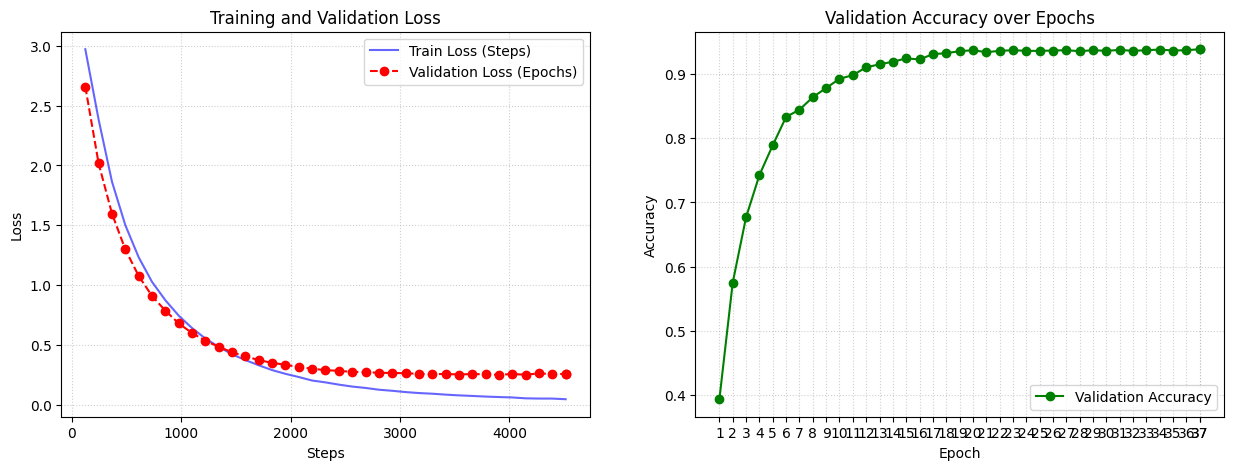

In [9]:
import lib.ml_metrics as ml_metrics
importlib.reload(ml_metrics)

metrics = ml_metrics.extract_metrics(trainer.state.log_history)
ml_metrics.plot_metrics(metrics)

In [10]:
# from sklearn.preprocessing import LabelEncoder
# import joblib
#
# cat_df  = pd.read_excel(root_path / 'data/full_marked.xlsx', sheet_name='Category')
# # Берём список всех категорий (номеров)
# category_ids = cat_df["Номер категории"].tolist()
#
# # Создаём LabelEncoder и обучаем на НОМЕРАХ категорий
# le = LabelEncoder()
# le.fit(category_ids)
#
# # Сохраняем
# joblib.dump(le, models_path / "label_encoder.pkl")
#
# # Применяем к твоим данным
# df["target_enc"] = le.transform(df["target"])
#
# print("Классы LabelEncoder:", le.classes_)
# print("Количество классов:", len(le.classes_))
# df["target"] = df["target_enc"]

In [11]:
print("\n--- Финальная оценка на тестовом множестве ---")
final_metrics = trainer.evaluate(eval_dataset=train_test["test"])

print(f"Accuracy: {final_metrics['eval_accuracy']:.4f}")
print(f"Precision: {final_metrics['eval_precision']:.4f}")
print(f"Recall: {final_metrics['eval_recall']:.4f}")
print(f"F1: {final_metrics['eval_f1']:.4f}")


--- Финальная оценка на тестовом множестве ---
Accuracy: 0.9390
Precision: 0.9375
Recall: 0.9390
F1: 0.9366
